In [1]:
!python -V

Python 3.11.5


# --------------------------------------------------------------------------------------

In [1]:
# Cell 1: Setup and Configuration
import json
import os
import sys
from pathlib import Path
from typing import List, Dict, Any
import hashlib

# Add project root to path
PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

from qdrant_client import QdrantClient, models
from qdrant_client.models import Distance, VectorParams, PointStruct
from fastembed import TextEmbedding

# Configuration
CHUNKED_DATA_DIR = PROJECT_ROOT / "data" / "chunked_data"
QDRANT_URL = "https://5ef7d200-3b5c-4874-8f95-e621d3d5d429.eu-central-1-0.aws.cloud.qdrant.io"
QDRANT_API_KEY = os.getenv("QDRANT_API_KEY")
COLLECTION_NAME = "survival_strategies"
EMBEDDING_MODEL = "BAAI/bge-base-en-v1.5"
EMBEDDING_DIMENSION = 768
BATCH_SIZE = 100

print("🎯 Configuration loaded for Survival Strategies RAG")

# Cell 2: Initialize Clients
def initialize_clients():
    """Initialize Qdrant client and embedding model"""
    # Initialize Qdrant Cloud client
    qdrant_client = QdrantClient(
        url=QDRANT_URL,
        api_key=QDRANT_API_KEY,
        timeout=60
    )
    
    # Initialize FastEmbed model
    embedding_model = TextEmbedding(model_name=EMBEDDING_MODEL)
    
    print("✅ Clients initialized successfully")
    return qdrant_client, embedding_model

🎯 Configuration loaded for Survival Strategies RAG


2025-10-18 19:20:01.980569010 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [2]:
qdrant_client, embedding_model = initialize_clients()

✅ Clients initialized successfully


In [3]:
# Cell 3: Setup Collection (Following the example pattern)
def setup_collection():
    """Setup Qdrant collection following the example pattern"""
    # Delete existing collection if needed (good for testing)
    try:
        qdrant_client.delete_collection(collection_name=COLLECTION_NAME)
        print(f"🗑️ Deleted existing collection: {COLLECTION_NAME}")
    except Exception:
        print(f"📚 No existing collection to delete: {COLLECTION_NAME}")
    
    # Create new collection
    qdrant_client.create_collection(
        collection_name=COLLECTION_NAME,
        vectors_config=VectorParams(
            size=EMBEDDING_DIMENSION,
            distance=Distance.COSINE
        )
    )
    print(f"📖 Created new collection: {COLLECTION_NAME} (dimension: {EMBEDDING_DIMENSION})")
      
    print("✅ Collection setup completed with indexes")

In [4]:
setup_collection()

🗑️ Deleted existing collection: survival_strategies
📖 Created new collection: survival_strategies (dimension: 768)
✅ Collection setup completed with indexes


In [7]:
# Cell 4: Load All Chunk Files (Similar to documents_raw in example)
def load_all_chunks() -> List[Dict[str, Any]]:
    """Load all chunks from all files in chunked_data directory"""
    all_chunks = []
    
    if not CHUNKED_DATA_DIR.exists():
        print(f"❌ Directory not found: {CHUNKED_DATA_DIR}")
        return all_chunks
    
    chunk_files = list(CHUNKED_DATA_DIR.glob("*.json"))
    print(f"📁 Found {len(chunk_files)} chunk files")
    
    for file_path in chunk_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                chunks = json.load(f)
                all_chunks.extend(chunks)
            print(f"📄 Loaded {len(chunks)} chunks from {file_path.name}")
        except Exception as e:
            print(f"❌ Error loading {file_path}: {e}")
    
    print(f"📊 Total chunks loaded: {len(all_chunks)}")
    return all_chunks

In [8]:
# Load all chunks (similar to documents in example)
all_chunks = load_all_chunks()

if all_chunks:
    print(f"Sample chunk: {json.dumps(all_chunks[4], indent=2)}")

📁 Found 97 chunk files
📄 Loaded 2 chunks from how_long_could_you_survive_mpox_monkeypox_20251018_143101.json
📄 Loaded 4 chunks from how_to_survive_being_a_mall_santa_20251018_143101.json
📄 Loaded 6 chunks from the_black_market_of_butt_injections_20251018_143101.json
📄 Loaded 6 chunks from how_to_survive_an_exploding_phone_20251018_143102.json
📄 Loaded 6 chunks from the_deadliest_tsunamis_in_human_history_20251018_143101.json
📄 Loaded 6 chunks from how_to_survive_a_brain_eating_amoeba_20251018_143102.json
📄 Loaded 7 chunks from how_to_survive_a_wildfire_20251018_143101.json
📄 Loaded 7 chunks from how_to_survive_eating_the_worlds_hottest_pepper_20251018_143101.json
📄 Loaded 6 chunks from how_to_survive_eating_raw_meat_20251018_143101.json
📄 Loaded 5 chunks from how_to_survive_being_locked_in_a_freezer_20251018_143101.json
📄 Loaded 2 chunks from how_to_survive_2021_20251018_143101.json
📄 Loaded 7 chunks from how_to_survive_a_collapsing_sand_dune_20251018_143101.json
📄 Loaded 6 chunks from

In [9]:
# Cell 5: Generate Points for Upsert (Adapted from example)
def generate_points_with_embeddings(chunks: List[Dict[str, Any]]) -> List[PointStruct]:
    """Generate points with embeddings for Qdrant upsert"""
    points = []
    
    # Extract texts for batch embedding
    texts = [chunk["text"] for chunk in chunks]
    
    print(f"🔢 Generating embeddings for {len(texts)} chunks...")
    
    # Generate embeddings in batch (much faster)
    embeddings = list(embedding_model.embed(texts))
    
    print(f"✅ Generated {len(embeddings)} embeddings")
    
    # Create points (similar to example but with our chunk structure)
    for i, (chunk, embedding) in enumerate(zip(chunks, embeddings)):
        # Create unique ID using hash of content (similar to example's incremental ID)
        content_str = f"{chunk['video_title']}{chunk['chapter_title']}{chunk['start_time']}{chunk['text']}"
        point_id = int(hashlib.sha256(content_str.encode()).hexdigest()[:16], 16)
        
        point = PointStruct(
            id=point_id,
            vector=embedding.tolist(),  # Convert numpy array to list
            payload={
                "video_title": chunk["video_title"],
                "chapter_title": chunk["chapter_title"], 
                "start_time": chunk["start_time"],
                "text": chunk["text"]
            }
        )
        points.append(point)
    
    return points

In [10]:
import psutil
import gc

def print_memory_usage():
    process = psutil.Process()
    memory_mb = process.memory_info().rss / 1024 / 1024
    print(f"🧠 Memory usage: {memory_mb:.1f} MB")

# Call this before/after each batch
print_memory_usage()

🧠 Memory usage: 1474.9 MB


In [20]:
# Cell 6: Batch Processing and Upsert
def upsert_all_chunks_in_batches(chunks: List[Dict[str, Any]], batch_size: int = BATCH_SIZE):
    """Upsert all chunks in batches to manage memory and API limits"""
    total_upserted = 0
    
    for i in range(0, len(chunks), batch_size):
        batch_chunks = chunks[i:i + batch_size]
        batch_number = (i // batch_size) + 1
        total_batches = (len(chunks) + batch_size - 1) // batch_size
        
        print(f"🔄 Processing batch {batch_number}/{total_batches} ({len(batch_chunks)} chunks)...")
        
        # Generate points with embeddings for this batch
        points = generate_points_with_embeddings(batch_chunks)
        
        # Upsert to Qdrant
        try:
            operation_info = qdrant_client.upsert(
                collection_name=COLLECTION_NAME,
                wait=True,
                points=points
            )
            
            if operation_info.status == models.UpdateStatus.COMPLETED:
                total_upserted += len(points)
                print(f"✅ Batch {batch_number} upserted successfully")
            else:
                print(f"⚠️ Batch {batch_number} upsert status: {operation_info.status}")
                
        except Exception as e:
            print(f"❌ Batch {batch_number} upsert failed: {e}")
    
    return total_upserted

In [15]:
def load_chunks_from_file(file_path: Path) -> List[Dict[str, Any]]:
    """Load chunks from a single JSON file"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            chunks = json.load(f)
        print(f"   📄 Loaded {len(chunks)} chunks from {file_path.name}")
        return chunks
    except Exception as e:
        print(f"   ❌ Error loading {file_path}: {e}")
        return []


def process_files_sequentially():
    """Process one chunk file at a time to minimize memory usage"""
    chunk_files = list(CHUNKED_DATA_DIR.glob("*.json"))
    
    if not chunk_files:
        print("❌ No chunk files found")
        return 0
    
    print(f"📁 Found {len(chunk_files)} chunk files to process")
    total_upserted = 0
    
    for file_index, file_path in enumerate(chunk_files, 1):
        print(f"\n📄 [{file_index}/{len(chunk_files)}] Processing {file_path.name}...")
        print_memory_usage()
        
        try:
            # Load only one file's chunks
            chunks = load_chunks_from_file(file_path)
            if not chunks:
                print(f"⏭️ No chunks in {file_path.name}, skipping")
                continue
            
            print(f"   📊 {len(chunks)} chunks loaded from file")
            
            # Process this file's chunks in small batches
            file_upserted = upsert_all_chunks_in_batches(chunks, batch_size=10)
            total_upserted += file_upserted
            
            print(f"✅ {file_path.name}: {file_upserted}/{len(chunks)} chunks upserted")
            
        except Exception as e:
            print(f"❌ Error processing {file_path.name}: {e}")
            continue  # Continue with next file even if one fails
        
        finally:
            # Always clean up memory
            if 'chunks' in locals():
                del chunks
            gc.collect()
            print_memory_usage()
    
    print(f"\n🎉 Sequential processing completed!")
    print(f"📊 Total chunks upserted: {total_upserted}")
    return total_upserted

def upsert_all_chunks_in_batches(chunks: List[Dict[str, Any]], batch_size: int = 10):
    """Upsert chunks in small batches with memory management"""
    total_upserted = 0
    total_batches = (len(chunks) + batch_size - 1) // batch_size
    
    for i in range(0, len(chunks), batch_size):
        batch_chunks = chunks[i:i + batch_size]
        batch_number = (i // batch_size) + 1
        
        print(f"   🔄 Batch {batch_number}/{total_batches} ({len(batch_chunks)} chunks)...")
        
        try:
            # Generate points with embeddings for this batch
            points = generate_points_with_embeddings(batch_chunks)
            
            # Upsert to Qdrant
            operation_info = qdrant_client.upsert(
                collection_name=COLLECTION_NAME,
                wait=True,
                points=points
            )
            
            if operation_info.status == models.UpdateStatus.COMPLETED:
                total_upserted += len(points)
                print(f"   ✅ Batch {batch_number} upserted successfully")
            else:
                print(f"   ⚠️ Batch {batch_number} upsert status: {operation_info.status}")
                
        except Exception as e:
            print(f"   ❌ Batch {batch_number} failed: {e}")
        
        finally:
            # Clean up batch memory
            if 'points' in locals():
                del points
            gc.collect()
    
    return total_upserted


In [16]:
# Cell 7: Execute Complete Upsert
if all_chunks:
    print("🚀 Starting sequential file processing...")
    total_upserted = process_files_sequentially()
    print(f"\n🏁 Processing complete! {total_upserted} total chunks upserted to Qdrant Cloud")
else:
    print("❌ Failed Miserably")


🚀 Starting sequential file processing...
📁 Found 97 chunk files to process

📄 [1/97] Processing how_long_could_you_survive_mpox_monkeypox_20251018_143101.json...
🧠 Memory usage: 1474.9 MB
   📄 Loaded 2 chunks from how_long_could_you_survive_mpox_monkeypox_20251018_143101.json
   📊 2 chunks loaded from file
   🔄 Batch 1/1 (2 chunks)...
🔢 Generating embeddings for 2 chunks...
✅ Generated 2 embeddings
   ✅ Batch 1 upserted successfully
✅ how_long_could_you_survive_mpox_monkeypox_20251018_143101.json: 2/2 chunks upserted
🧠 Memory usage: 1477.7 MB

📄 [2/97] Processing how_to_survive_being_a_mall_santa_20251018_143101.json...
🧠 Memory usage: 1477.7 MB
   📄 Loaded 4 chunks from how_to_survive_being_a_mall_santa_20251018_143101.json
   📊 4 chunks loaded from file
   🔄 Batch 1/1 (4 chunks)...
🔢 Generating embeddings for 4 chunks...
✅ Generated 4 embeddings
   ✅ Batch 1 upserted successfully
✅ how_to_survive_being_a_mall_santa_20251018_143101.json: 4/4 chunks upserted
🧠 Memory usage: 1478.0 MB



In [20]:
# Cell 8: Verify Collection
def verify_collection():
    """Verify the collection was populated correctly"""
    try:
        collection_info = qdrant_client.get_collection(COLLECTION_NAME)
        print(f"📊 Collection Info:")
        print(f"   - Points count: {collection_info.points_count}")
        print(f"   - Vectors count: {collection_info.vectors_count}")
        
        # Test search
        test_query = "How to survive a bear attack"
        test_embedding = list(embedding_model.embed([test_query]))[0]
        
        search_results = qdrant_client.search(
            collection_name=COLLECTION_NAME,
            query_vector=test_embedding.tolist(),
            limit=5
        )
        
        print(f"🔍 Test search for '{test_query}':")
        for i, result in enumerate(search_results):
            print(f"   {i+1}. Score: {result.score:.3f}")
            print(f"      Video: {result.payload['video_title']}")
            print(f"      Chapter: {result.payload['chapter_title']}")
            print(f"      Text: {result.payload['text'][:100]}...")
            
    except Exception as e:
        print(f"❌ Verification failed: {e}")

In [21]:
verify_collection()

📊 Collection Info:
   - Points count: 610
   - Vectors count: None


/tmp/ipykernel_123377/2623121270.py:14: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  search_results = qdrant_client.search(


🔍 Test search for 'How to survive a bear attack':
   1. Score: 0.779
      Video: How to Survive a Wildfire
      Chapter: Call for help
      Text: Let the authorities know about the fire and your last known location. That way, they have a better c...
   2. Score: 0.728
      Video: How to Survive Being Lost in the Andes Mountains
      Chapter: Find Shelter
      Text: navigating around in the dark. If you have brought a tent or a tarp, use it to build your shelter fo...
   3. Score: 0.699
      Video: How to Survive Being Lost in the Andes Mountains
      Chapter: Self-Rescue
      Text: Surviving pretty much relies on your abilities now. Hike and move about during the day, and rest as ...
   4. Score: 0.695
      Video: Top 5 Basic Survival Skills
      Chapter: Get water
      Text: Hydrating is the most important thing you should do. If you're near a lake or river, great. But if y...
   5. Score: 0.688
      Video: Household Items That Could Save You in a Nuclear War
      Chapte

In [35]:
def vector_search(question):
    print('vector_search is used')
    
    
    query_points = qdrant_client.query_points(
        collection_name=COLLECTION_NAME,
        query=models.Document(
            text=question,
            model=EMBEDDING_MODEL 
        ),

        limit=5,
        with_payload=True
    )
    
    results = []
    
    for point in query_points.points:
        results.append(point.payload)
    
    return results

In [36]:
question = 'Should I go near a flyover during a hurricane?'

In [37]:
search_results = vector_search(question)

vector_search is used


In [ ]:
search_results

In [ ]:
query = "WHy people like Matt Suter are famous?"
# Convert generator → list
embeddings = list(embedding_model.embed([query]))
query_vec = embeddings[0]  # now you can index safely

results = qdrant_client.search(
    collection_name=COLLECTION_NAME,
    query_vector=query_vec,
    limit=5,
    with_payload=True
)

for r in results:
    print(r.score)
    print("  title:", r.payload.get("video_title"))
    print("  chapter:", r.payload.get("chapter_title"))
    print("  text preview:", (r.payload.get("text")[:300] or ""))
    print()


In [67]:
def get_all_point_ids(collection_name, limit=1000):
    """Scroll through all points in the collection and collect their IDs."""
    all_ids = []
    next_page = None

    while True:
        points, next_page = qdrant_client.scroll(
            collection_name=collection_name,
            limit=limit,
            offset=next_page
        )
        all_ids.extend([p.id for p in points])
        if next_page is None:
            break  # no more pages
    return all_ids

# Example usage
all_ids = get_all_point_ids(COLLECTION_NAME, limit=500)
print(f"✅ Retrieved {len(all_ids)} point IDs.")

✅ Retrieved 610 point IDs.


In [ ]:
import random

# 1. scroll & collect IDs
points, _ = qdrant_client.scroll(collection_name=COLLECTION_NAME, limit=1000)
all_ids = [p.id for p in points]

# 2. random sample
sample_ids = random.sample(all_ids, min(20, len(all_ids)))

# 3. retrieve + neighbor search
for sid in sample_ids:
    pt = qdrant_client.retrieve(
        collection_name=COLLECTION_NAME,
        ids=[sid],
        with_vectors=True,    # ✅ fixed
        with_payload=True
    )[0]

    vec = pt.vector
    neighbors = qdrant_client.search(
        collection_name=COLLECTION_NAME,
        query_vector=vec,
        limit=6,
        with_payload=True
    )

    print("=== Point:", sid, "title:", pt.payload.get("video_title"))
    for n in neighbors:
        print("   ->", n.id, f"score={n.score:.4f}", "title:", n.payload.get("video_title"))
    print()



In [98]:
print(type(qdrant_client))


<class 'qdrant_client.qdrant_client.QdrantClient'>


In [ ]:
import random, statistics

sample_ids = random.sample(all_ids, min(100, len(all_ids)))
avg_top1_scores = []
for sid in sample_ids:
    pt = qdrant_client.retrieve(collection_name=COLLECTION_NAME, ids=[sid], with_vector=True)[0]
    vec = pt.vector
    res = qdrant_client.search(collection_name=COLLECTION_NAME, query_vector=vec, limit=6)
    # ignore self if present
    neigh_scores = [r.score for r in res if r.id != sid][:5]
    if neigh_scores:
        avg_top1_scores.append(neigh_scores[0])
print("samples:", len(avg_top1_scores))
print("top1 score mean:", statistics.mean(avg_top1_scores))
print("top1 score median:", statistics.median(avg_top1_scores))
print("top1 score min/max:", min(avg_top1_scores), max(avg_top1_scores))


In [100]:
import qdrant_client
from qdrant_client import QdrantClient
print("qdrant_client object:", qdrant_client)
print("type(qdrant_client):", type(qdrant_client))

# try to find any QdrantClient instance in globals()
instances = [v for v in globals().values() if isinstance(v, QdrantClient)]
print("Found QdrantClient instances in globals():", instances)


qdrant_client object: <module 'qdrant_client' from '/home/sidd4ml/.pyenv/versions/3.11.5/lib/python3.11/site-packages/qdrant_client/__init__.py'>
type(qdrant_client): <class 'module'>
Found QdrantClient instances in globals(): [<qdrant_client.qdrant_client.QdrantClient object at 0x7f9f7f6b8450>, <qdrant_client.qdrant_client.QdrantClient object at 0x7f9f7f6b8450>]


In [99]:
from qdrant_client import QdrantClient
import qdrant_client as qmod

# try common names first
client = None
for name in ("qdrant_client", "client", "qd_client", "qc"):
    obj = globals().get(name)
    if isinstance(obj, QdrantClient):
        client = obj
        print(f"Using existing client in variable '{name}'")
        break

# fallback: search for any QdrantClient instance in globals()
if client is None:
    for v in globals().values():
        if isinstance(v, QdrantClient):
            client = v
            print("Found QdrantClient instance in globals()")
            break

# last resort: create a new client pointing at localhost
if client is None:
    print("No existing QdrantClient instance found — creating new QdrantClient(url='http://localhost:6333')")
    client = QdrantClient(url="http://localhost:6333")

# use `client` from now on (not the module)
print("client variable ready:", client)


Using existing client in variable 'qdrant_client'
client variable ready: <qdrant_client.qdrant_client.QdrantClient object at 0x7f9f7f6b8450>


In [101]:
import random, statistics

# get up to 1000 points (unpack returned tuple)
points, _ = client.scroll(collection_name=COLLECTION_NAME, limit=1000, with_vectors=True)
all_ids = [p.id for p in points]

# sample some points and compute neighbor top1 stats
sample_ids = random.sample(all_ids, min(100, len(all_ids)))
top1_scores = []

for sid in sample_ids:
    # find the point locally (we have points from scroll); fallback to retrieve if not present
    pt = next((p for p in points if p.id == sid), None)
    if pt is None:
        # fallback: retrieve (client must be a QdrantClient instance)
        try:
            pt = client.retrieve(collection_name=COLLECTION_NAME, ids=[sid], with_vectors=True)[0]
        except Exception as e:
            print(f"Warning: failed to get point {sid}: {e}")
            continue

    vec = getattr(pt, "vector", None) or getattr(pt, "vectors", None)
    if vec is None:
        print(f"Warning: no vector for {sid}")
        continue

    hits = client.search(collection_name=COLLECTION_NAME, query_vector=list(vec), limit=6)
    neigh_scores = [h.score for h in hits if h.id != sid]
    if neigh_scores:
        top1_scores.append(neigh_scores[0])

if top1_scores:
    print("samples:", len(top1_scores))
    print("mean:", statistics.mean(top1_scores))
    print("median:", statistics.median(top1_scores))
    print("min/max:", min(top1_scores), max(top1_scores))
else:
    print("No neighbor scores collected.")


/tmp/ipykernel_123377/1893591063.py:27: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  hits = client.search(collection_name=COLLECTION_NAME, query_vector=list(vec), limit=6)


samples: 100
mean: 0.7708424715
median: 0.7713089
min/max: 0.6646427 0.86578107


In [103]:
!pip install matplotlib

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 4.0 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 4.0 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib]5 [matplotlib]


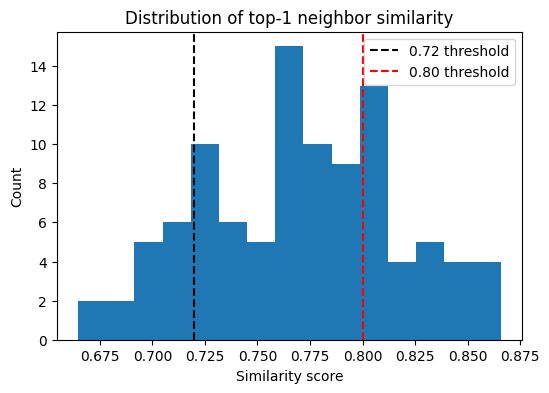

In [104]:
import matplotlib.pyplot as plt

# top1_scores should be the list you computed; if not, assign it first.
# top1_scores = avg_top1_scores  # if you still have it

plt.figure(figsize=(6,4))
plt.hist(top1_scores, bins=15)
plt.title("Distribution of top-1 neighbor similarity")
plt.xlabel("Similarity score")
plt.ylabel("Count")
plt.axvline(0.72, color='k', linestyle='--', label='0.72 threshold')
plt.axvline(0.8, color='r', linestyle='--', label='0.80 threshold')
plt.legend()
plt.show()

{
  "limit": 700,
   "color_by": {
     "payload": "video_title"
   }
}